In [1]:
import glob 
import os
import math
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plot

In [2]:
import matplotlib as mpl
mpl.rcParams['font.size'] = 10  # Default font size for general text
mpl.rcParams['axes.labelsize'] = 11 # Font size for axis labels
mpl.rcParams['xtick.labelsize'] = 9 # Font size for x-axis tick labels
mpl.rcParams['ytick.labelsize'] = 9 # Font size for y-axis tick labels
mpl.rcParams['legend.fontsize'] = 9 # Font size for legend
mpl.rcParams['axes.titlesize'] = 11 # Font size for plot title

In [6]:
# file names of `clouds` file is extrapolated based on these file paths as well.
levels_withneg_l = [
	"/home/kd766/quorum-sensing/outputs/04112025064926_size-100x100_select-0.3_seed-0.025/04112025064926_size-100x100_select-0.3_seed-0.025_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/06262025214226_size-100x100_select-0.8_seed-0.03/06262025214226_size-100x100_select-0.8_seed-0.03_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/04112025064724_size-100x100_select-0.3_seed-0.0333/04112025064724_size-100x100_select-0.3_seed-0.0333_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/06262025214211_size-100x100_select-0.8_seed-0.05/06262025214211_size-100x100_select-0.8_seed-0.05_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/05292025212917_size-100x100_select-1_seed-0.0667/05292025212917_size-100x100_select-1_seed-0.0667_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/05292025180028_size-100x100_select-0.3_seed-0.1/05292025180028_size-100x100_select-0.3_seed-0.1_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/05292025180016_size-100x100_select-0.3_seed-0.125/05292025180016_size-100x100_select-0.3_seed-0.125_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/05292025174657_size-100x100_select-0.4_seed-0.15/05292025174657_size-100x100_select-0.4_seed-0.15_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/05292025180030_size-100x100_select-0.3_seed-0.175/05292025180030_size-100x100_select-0.3_seed-0.175_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/05292025180015_size-100x100_select-0.3_seed-0.2/05292025180015_size-100x100_select-0.3_seed-0.2_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/06262025142707_size-100x100_select-0.3_seed-0.225/06262025142707_size-100x100_select-0.3_seed-0.225_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/06262025142751_size-100x100_select-0.3_seed-0.25/06262025142751_size-100x100_select-0.3_seed-0.25_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/06262025142714_size-100x100_select-0.3_seed-0.275/06262025142714_size-100x100_select-0.3_seed-0.275_levels_final.csv",
]

levels_noneg_l = [
	"/home/kd766/quorum-sensing/outputs/07232025152722_size-100x100_select-0.3_seed-0.025_noneg/07232025152722_size-100x100_select-0.3_seed-0.025_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025162644_size-100x100_select-0.3_seed-0.03_noneg/07232025162644_size-100x100_select-0.3_seed-0.03_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025152745_size-100x100_select-0.3_seed-0.0333_noneg/07232025152745_size-100x100_select-0.3_seed-0.0333_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025162614_size-100x100_select-0.3_seed-0.05_noneg/07232025162614_size-100x100_select-0.3_seed-0.05_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025152552_size-100x100_select-0.3_seed-0.0667_noneg/07232025152552_size-100x100_select-0.3_seed-0.0667_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025152554_size-100x100_select-0.3_seed-0.1_noneg/07232025152554_size-100x100_select-0.3_seed-0.1_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025152556_size-100x100_select-0.3_seed-0.125_noneg/07232025152556_size-100x100_select-0.3_seed-0.125_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025152621_size-100x100_select-0.3_seed-0.15_noneg/07232025152621_size-100x100_select-0.3_seed-0.15_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025152648_size-100x100_select-0.3_seed-0.175_noneg/07232025152648_size-100x100_select-0.3_seed-0.175_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025152708_size-100x100_select-0.3_seed-0.2_noneg/07232025152708_size-100x100_select-0.3_seed-0.2_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025164017_size-100x100_select-0.3_seed-0.225_noneg/07232025164017_size-100x100_select-0.3_seed-0.225_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025164023_size-100x100_select-0.3_seed-0.25_noneg/07232025164023_size-100x100_select-0.3_seed-0.25_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025164056_size-100x100_select-0.3_seed-0.275_noneg/07232025164056_size-100x100_select-0.3_seed-0.275_noneg_levels_final.csv",
]

In [44]:
def plot_all_histograms(feedback_str, level_ax, plotstyle):
    
    if feedback_str == '':
        filter_func = lambda x: 'noneg' not in x 
    else:
        filter_func = lambda x: 'noneg' in x
    
    levels_l = levels_noneg_l if feedback_str=="noneg" else levels_withneg_l
    n_trials = len(levels_l)
    print(f"Total # trials: {n_trials}")

    # infer all densities and pre-order them into a list.
    density_str_l = []
    for idx, (level_file) in enumerate(levels_l):
        dirpath, fname = os.path.split(level_file)
        parts = fname.split('_')
        cloud_file = os.path.join(dirpath, '_'.join(parts[:-2]) + '_clouds_final.csv')
        density = float(parts[3].split('-')[-1])
        density_str = str(round(density, 4))
        density_str_l.append(density_str)

        # find n_cells based on levels.
        levels = pd.read_csv(level_file, header=None).to_numpy().flatten()
        n_cells = np.sum(levels!=0)
        n_bins = int(n_cells**0.5)

        # plot histogram.
        cloud = pd.read_csv(cloud_file, header=None).to_numpy().flatten()
        level_ax.hist(cloud.flatten(), label=f"{round(density*100, 2)}", bins=8, alpha=0.2)
    level_ax.legend()

Total # trials: 13


/tmp/ipykernel_59908/2683311837.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plot.legend()


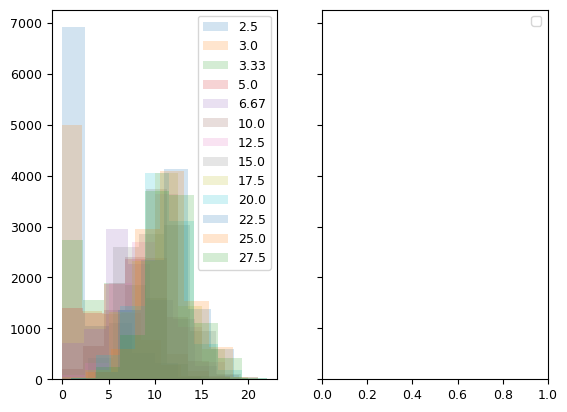

In [45]:
fig, axs = plot.subplots(1, 2, sharey=True)
plot_all_histograms('', axs[0], '')
plot.legend()
plot.show()